In [304]:
import os 
import pandas as pd 
import numpy as np

import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px 
import plotly.graph_objects as go

from pathlib import Path 

ROOT = Path.cwd().parents[1] 
EMBED_PATH = ROOT / "data/embeddings/pretrained" 
EMBED_NAME = EMBED_PATH.stem 

IMAGE_DIR = ROOT / "images/stats" / EMBED_NAME 
RESULTS_DIR = ROOT / "data/results" / EMBED_NAME

In [305]:
os.makedirs(IMAGE_DIR, exist_ok=True)

In [306]:
mal_aurocs = pd.read_csv(RESULTS_DIR / "aurocs.csv", index_col=0)["mal_aurocs"] 

cls_cluster = pd.read_csv(RESULTS_DIR / "cluster_results.csv", index_col=0) 
patch_cluster = pd.read_csv(RESULTS_DIR / "patch_embed_summary.csv", index_col=0)

defect_coverage = (
    pd.read_csv("../../data/results/data_analysis/defect_coverage_stats.csv")
    [["category", "mean"]]
    .set_index("category")
    .rename(columns={"mean": "Defect Coverage"})
)

display_names = {
    "silhouette": "Silhouette",
    "davies_bouldin": "Davies-Bouldin",
    "cal_har": "Calinski-Harabasz",
    "normal_inter": "Normal Inter Dist.",
    "defect_inter": "Defect Inter Dist.",
    "separation": "Separation Ratio",
    "normal_intra": "Normal Intra Dist.",
    "defect_intra": "Defect Intra Dist.",
    "train_intra": "Train Intra Dist.",
    "intra_ratio": "Intra Ratio",
}

cls_cluster = cls_cluster.rename(
    index=display_names,
    columns=display_names,
)

patch_cluster = patch_cluster.rename(
    index=display_names,
    columns=display_names
)

mal_aurocs = mal_aurocs.rename("AUROC")

In [307]:
combined = defect_coverage.join(mal_aurocs)

# Rename if necessary
combined = combined.rename(columns={
    "mal_aurocs": "AUROC",
})

plot_df = combined.reset_index(names="category")
no_screw = plot_df[plot_df["category"] != "screw"]


# --- All categories ---
fig = px.scatter(
    plot_df,
    x="Defect Coverage",
    y="AUROC",
    text="category",
    hover_name="category",
    trendline="ols",
)

r_all = plot_df["Defect Coverage"].corr(plot_df["AUROC"])

results_all = px.get_trendline_results(fig)
fit_all = results_all.iloc[0]["px_fit_results"]
r2_all = fit_all.rsquared

fig.data[0].showlegend = False
fig.data[1].line.color = "red"
fig.data[1].name = (
    f"All categories: r = {r_all:.3f}, R² = {r2_all:.3f}"
)
fig.data[1].showlegend = True


# Excluding screw
fig_no_screw = px.scatter(
    no_screw,
    x="Defect Coverage",
    y="AUROC",
    trendline="ols",
)

r_no_screw = no_screw["Defect Coverage"].corr(no_screw["AUROC"])

results_no_screw = px.get_trendline_results(fig_no_screw)
fit_no_screw = results_no_screw.iloc[0]["px_fit_results"]
r2_no_screw = fit_no_screw.rsquared

# Grab only the trendline from the temporary figure
no_screw_line = fig_no_screw.data[1]

no_screw_line.line.color = "blue"
no_screw_line.line.dash = "dash"
no_screw_line.name = (
    f"Excluding screw: r = {r_no_screw:.3f}, "
    f"R² = {r2_no_screw:.3f}"
)
no_screw_line.showlegend = True

fig.add_trace(no_screw_line)


fig.update_traces(textposition="top center")

fig.update_layout(
    title=None,
    legend=dict(
        orientation="h",
        x=0.5,
        y=-0.25,
        xanchor="center",
        yanchor="top",
    ),
    margin=dict(b=100),
)

fig.write_image(
    IMAGE_DIR / "defect_coverage_auroc.svg",
    width=1200,
    height=450
)
fig.show()

In [308]:
combined = cls_cluster.join(mal_aurocs) 

combined

,Silhouette,Normal Inter Dist.,Defect Inter Dist.,Separation Ratio,Normal Intra Dist.,Defect Intra Dist.,Davies-Bouldin,Calinski-Harabasz,AUROC
category,,,,,,,,,
tile,0.051925,13.828683,30.462551,2.202853,13.194844,25.503618,2.151681,13.841351,1.000
zipper,0.054824,10.680494,17.839172,1.670257,10.037414,14.769583,2.255279,14.878088,0.987
toothbrush,0.010358,10.852008,19.439436,1.791322,10.421845,16.982060,2.601975,3.649014,0.972
hazelnut,0.035357,17.768284,23.515533,1.323456,16.975285,21.654016,3.417890,7.660800,0.949
wood,0.078673,21.327713,28.108612,1.317938,18.945887,23.288946,2.460468,8.035849,0.944
grid,0.075255,19.194645,22.477043,1.171006,18.273794,19.301464,2.893122,6.656239,0.983
cable,0.005631,17.824223,22.918423,1.285802,17.336468,22.108635,5.485366,4.156659,0.945
leather,0.161544,11.415674,26.463190,2.318145,9.138710,17.966806,1.505843,27.550618,1.000
metal_nut,0.008135,12.177718,15.678945,1.287511,11.461515,14.659174,3.217935,5.634620,0.983


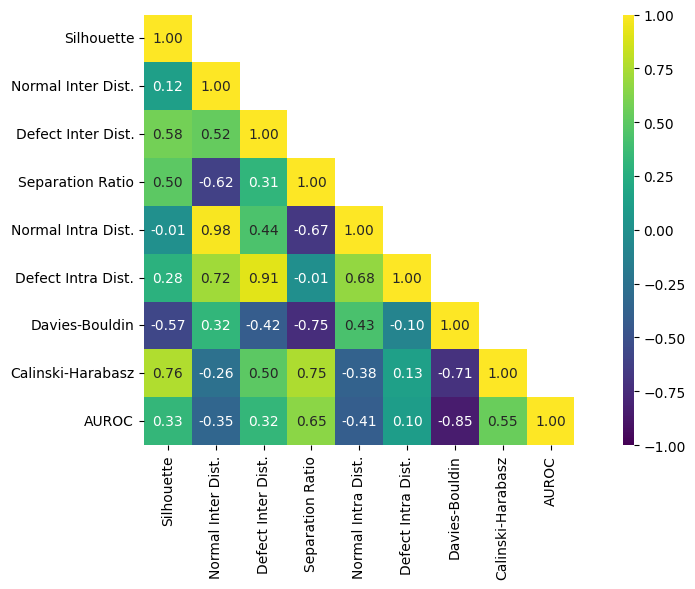

In [309]:
cor_cof = combined.corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/cls_corr.svg")
plt.show()

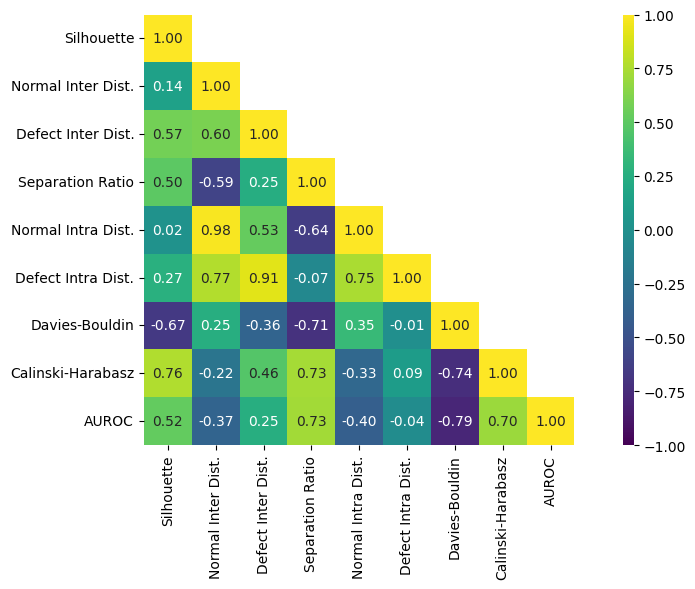

In [310]:
cor_cof = combined.drop(index="screw").corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/cls_no_screw_corr.svg")
plt.show()

In [311]:
plot_df = combined.reset_index()

fig = px.scatter(
    plot_df, 
    x="Separation Ratio", 
    y="AUROC", 
    text="category", 
    hover_name="category", 
    trendline="ols",
)
 
fig.data[1].line.color = "red"

r = plot_df["Separation Ratio"].corr(plot_df["AUROC"])

results = px.get_trendline_results(fig)
fit = results.iloc[0]["px_fit_results"]
r2 = fit.rsquared

fig.data[0].showlegend = False

# Existing OLS trendline trace
fig.data[1].line.color = "red"
fig.data[1].name = f"OLS fit: r = {r:.3f}, R² = {r2:.3f}"
fig.data[1].showlegend = True

fig.update_traces(textposition="top center")

fig.update_layout(
    title=None,
    legend=dict(
        x=0.425,
        y=-0.3,
        xanchor="left",
    )
)

fig.show() 
fig.write_image(
    IMAGE_DIR / "cls_mal_sep_plot.svg",
    width=1200,
    height=450
)

In [314]:
fig = px.scatter(
    plot_df,
    x="Davies-Bouldin",
    y="AUROC",
    text="category",
    hover_name="category",
    trendline="ols"
)

# Trendline styling
fig.data[1].line.color = "red"

r = plot_df["Davies-Bouldin"].corr(plot_df["AUROC"])

results = px.get_trendline_results(fig)
fit = results.iloc[0]["px_fit_results"]
r2 = fit.rsquared

fig.data[0].showlegend = False

# Existing OLS trendline trace
fig.data[1].line.color = "red"
fig.data[1].name = f"OLS fit: r = {r:.3f}, R² = {r2:.3f}"
fig.data[1].showlegend = True

fig.update_traces(textposition="top center")

fig.update_layout(
    title=None,
    legend=dict(
        x=0.425,
        y=-0.3,
        xanchor="left",
    )
)


fig.write_image(
    IMAGE_DIR / "cls_auroc_db_plot.svg",
    width=1250,
    height=450
)
fig.show()

In [295]:
patch_combined = patch_cluster.join(mal_aurocs) 

patch_combined = patch_combined.rename(
    index=display_names,
    columns=display_names,
)

patch_combined

,Silhouette,Davies-Bouldin,Calinski-Harabasz,Normal Inter Dist.,Defect Inter Dist.,Separation Ratio,Normal Intra Dist.,Defect Intra Dist.,Train Intra Dist.,Intra Ratio,AUROC
category,,,,,,,,,,,
bottle,0.1032,2.0161,21.0375,35.5670,38.7165,1.0888,33.8505,24.6126,34.6712,0.9763,1.000
cable,0.1234,2.0764,17.4583,36.3120,42.2481,1.1644,34.2263,27.7112,35.7712,0.9568,0.945
capsule,0.1103,1.4781,8.0617,37.6489,45.1315,1.1989,37.0514,20.1856,37.4239,0.9900,0.941
carpet,0.2666,1.1308,25.0733,28.0213,44.2434,1.5799,24.8757,15.8434,25.2850,0.9838,0.980
grid,0.2727,1.1495,22.8300,29.8463,44.9653,1.5073,24.6649,16.2601,27.4793,0.8976,0.983
hazelnut,0.1479,1.4992,19.9355,39.1841,47.6354,1.2157,37.6479,23.3492,38.9374,0.9669,0.949
leather,0.2748,0.9460,14.5154,30.8956,49.6409,1.6115,26.4941,12.5874,24.4616,1.0831,1.000
metal_nut,0.0924,2.0189,31.2216,37.5273,37.4852,0.9997,34.3597,25.8242,36.5529,0.9400,0.983
pill,0.0977,1.7748,14.5052,37.9695,42.7971,1.1274,36.5540,23.9242,37.7873,0.9674,0.950


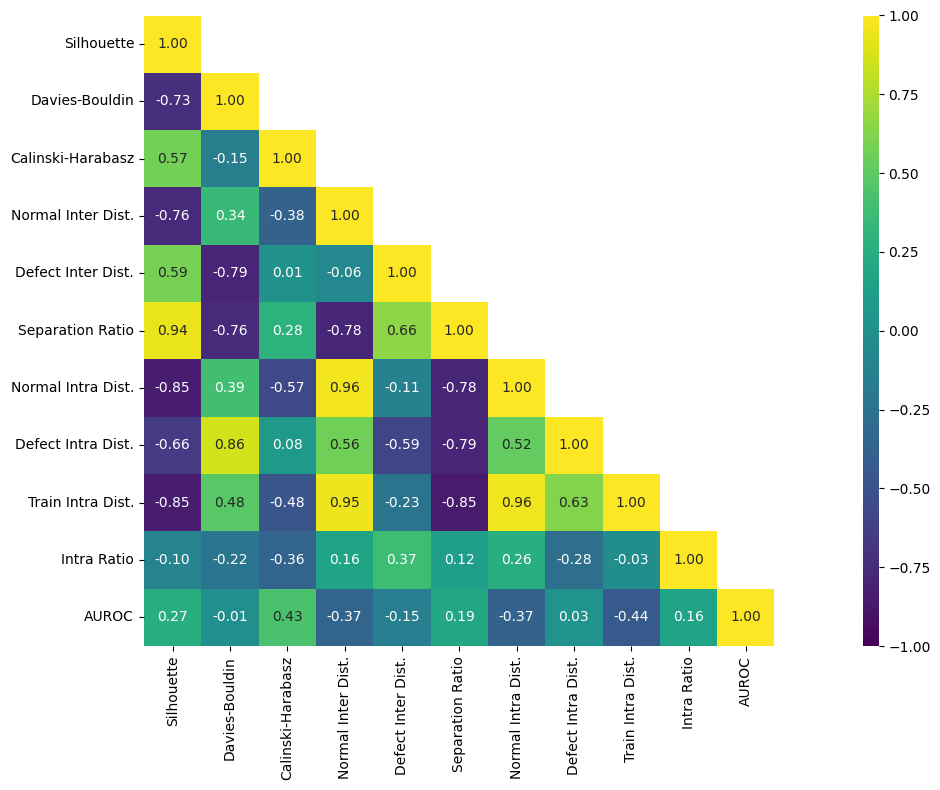

In [315]:
cor_cof = patch_combined.corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(18, 8)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/patch_corr.svg")
plt.show()

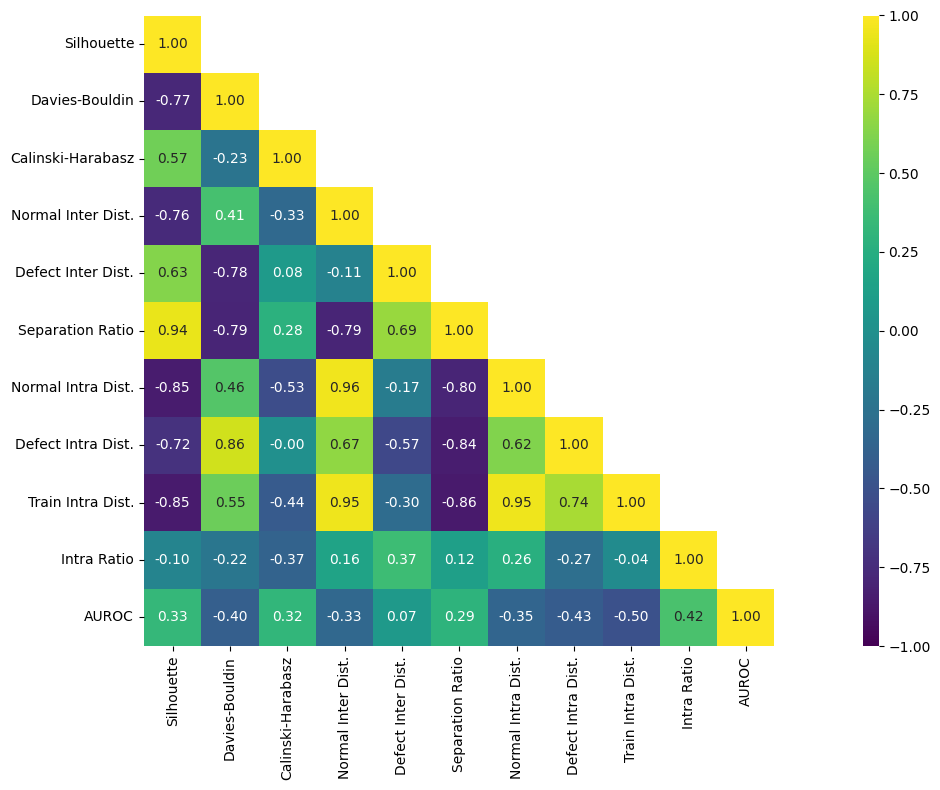

In [316]:
cor_cof = patch_combined.drop(index="screw").corr() 
mask = np.triu(np.ones_like(cor_cof, dtype=bool), k=1) # Correlation is symmetric, so we only need to show one triangle of the matrix 

plt.figure(figsize=(18, 8)) 
sns.heatmap(cor_cof, mask=mask, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.columns, square=True, annot_kws={"size": 10}) 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/patch_no_screw_corr.svg")
plt.show()

In [317]:
fig = px.scatter(patch_combined.reset_index(), 
                x="Defect Intra Dist.",
                y="AUROC", 
                text="category", 
                hover_name="category", 
                trendline="ols" 
            ) 
fig.data[1].line.color = "red" 
fig.update_traces(textposition="top center") 
fig.show() 

fig.write_image(
    IMAGE_DIR / "patch_mal_def_intra.svg",
    width=1200,
    height=450
)

In [299]:
cls_pref = cls_cluster.add_prefix("CLS ")
patch_pref = patch_cluster.add_prefix("Patch ")

combined = cls_pref.join(patch_pref).join(mal_aurocs)

combined

,CLS Silhouette,CLS Normal Inter Dist.,CLS Defect Inter Dist.,CLS Separation Ratio,CLS Normal Intra Dist.,CLS Defect Intra Dist.,CLS Davies-Bouldin,CLS Calinski-Harabasz,Patch Silhouette,Patch Davies-Bouldin,Patch Calinski-Harabasz,Patch Normal Inter Dist.,Patch Defect Inter Dist.,Patch Separation Ratio,Patch Normal Intra Dist.,Patch Defect Intra Dist.,Patch Train Intra Dist.,Patch Intra Ratio,AUROC
category,,,,,,,,,,,,,,,,,,,
tile,0.051925,13.828683,30.462551,2.202853,13.194844,25.503618,2.151681,13.841351,0.2694,1.4006,56.9894,32.4100,45.3849,1.3964,25.9535,22.2262,26.6325,0.9745,1.000
zipper,0.054824,10.680494,17.839172,1.670257,10.037414,14.769583,2.255279,14.878088,0.0830,1.7521,12.1111,33.2571,37.3918,1.1236,31.2610,19.5223,32.1882,0.9712,0.987
toothbrush,0.010358,10.852008,19.439436,1.791322,10.421845,16.982060,2.601975,3.649014,0.1060,1.7726,13.9147,37.6068,43.5274,1.1573,36.3193,25.1748,37.0921,0.9792,0.972
hazelnut,0.035357,17.768284,23.515533,1.323456,16.975285,21.654016,3.417890,7.660800,0.1479,1.4992,19.9355,39.1841,47.6354,1.2157,37.6479,23.3492,38.9374,0.9669,0.949
wood,0.078673,21.327713,28.108612,1.317938,18.945887,23.288946,2.460468,8.035849,0.2768,1.4002,40.1426,30.4740,42.6916,1.4054,23.5885,20.3072,28.6674,0.8228,0.944
grid,0.075255,19.194645,22.477043,1.171006,18.273794,19.301464,2.893122,6.656239,0.2727,1.1495,22.8300,29.8463,44.9653,1.5073,24.6649,16.2601,27.4793,0.8976,0.983
cable,0.005631,17.824223,22.918423,1.285802,17.336468,22.108635,5.485366,4.156659,0.1234,2.0764,17.4583,36.3120,42.2481,1.1644,34.2263,27.7112,35.7712,0.9568,0.945
leather,0.161544,11.415674,26.463190,2.318145,9.138710,17.966806,1.505843,27.550618,0.2748,0.9460,14.5154,30.8956,49.6409,1.6115,26.4941,12.5874,24.4616,1.0831,1.000
metal_nut,0.008135,12.177718,15.678945,1.287511,11.461515,14.659174,3.217935,5.634620,0.0924,2.0189,31.2216,37.5273,37.4852,0.9997,34.3597,25.8242,36.5529,0.9400,0.983


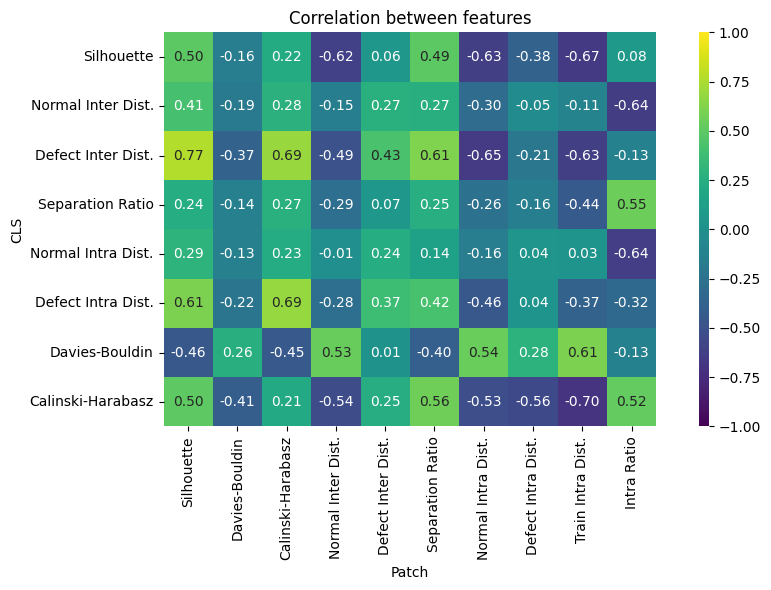

In [300]:
cls_cols = [c for c in combined.columns if c.startswith("CLS ")]
patch_cols = [c for c in combined.columns if c.startswith("Patch ")]

cor_cof = combined.corr() 
cor_cof = cor_cof.loc[cls_cols, patch_cols] 

cor_cof.index = cor_cof.index.str.removeprefix("CLS ")
cor_cof.columns = cor_cof.columns.str.removeprefix("Patch ")

cor_cof.index.name = "CLS"
cor_cof.columns.name = "Patch"

plt.figure(figsize=(10, 6)) 
sns.heatmap(cor_cof, annot=True, vmin=-1, vmax=1, cbar_kws={"aspect": 40}, cmap="viridis", fmt=".2f", xticklabels=cor_cof.columns, yticklabels=cor_cof.index, square=True, annot_kws={"size": 10}) 
plt.title("Correlation between features") 
plt.tight_layout() 

plt.savefig(f"{IMAGE_DIR}/cls_patch_corr.svg")
plt.show()

In [301]:
fig = px.scatter(combined.reset_index(), x="Patch Silhouette", y="CLS Defect Inter Dist.", text="category", hover_name="category", trendline="ols", color="AUROC", color_continuous_scale="Viridis") 
fig.data[1].line.color = "red" 
fig.update_traces(textposition="top center") 
fig.show() 

fig.write_image(IMAGE_DIR / "cls_def_inter_patch_sil.svg")

In [302]:
fig = px.scatter(combined.reset_index(), x="Patch Intra Ratio", y="CLS Separation Ratio", text="category", hover_name="category", trendline="ols", color="AUROC", color_continuous_scale="Viridis" ) 
fig.data[1].line.color = "red" 
fig.update_traces(textposition="top center") 
fig.show() 
fig.write_image(IMAGE_DIR / "cls_sep_patch_intra_ratio.svg")

In [303]:
fig = px.scatter(combined.reset_index(), x="Patch Train Intra Dist.", y="CLS Davies-Bouldin", text="category", hover_name="category", trendline="ols", color="AUROC", color_continuous_scale="Viridis" ) 
fig.data[1].line.color = "red" 
fig.update_traces(textposition="top center") 
fig.show() 

fig.write_image(IMAGE_DIR / "cls_db_patch_train_intra.svg")